# Case Study — Group 11

## 1. Introduction
### 1.1 Objective

## 2. Project Setup
### 2.1 Imports and Configuration
### 2.2 File Structure and Paths

## 3. Importing and Exploring the Data
### 3.1 Vehicle Data
### 3.2 Vehicle Component Lists
### 3.3 Engine Data
### 3.4 Gearshift Data
### 3.5 Component Part Lists
### 3.6 Single-Part Data
### 3.7 Geodata and Registration Data

## 4. Data Preparation
### 4.1 Selection of Vehicles Produced in 2015
### 4.2 Selection of Engine and Gearshift Components
### 4.3 Selection of Corresponding Parts
### 4.4 Data Cleaning and Validation

## 5. Data Integration and Supply Chain Reconstruction
### 5.1 Vehicles and Components
### 5.2 Components and Parts
### 5.3 Production Locations
### 5.4 Distribution Centers and Customers
### 5.5 Merge Validation

# Case Study — Group 11

# 1. Introduction

## 1.1 Objective

The task is to reconstruct the supply chain of vehicles produced by OEM1 in 2015 and to determine the total logistics distance travelled before the vehicles reach their customers. The analysis focuses on the engine and gearshift components as well as the corresponding parts installed in these components. For each relevant vehicle, the routes from the parts suppliers to the component suppliers, from the component suppliers to the OEM1 production plant, and from the production plant via the responsible distribution center to the customer are identified.

# 2. Project Setup

The original folders are stored below `data/IDA SoSe26 - Data`. Needed modules are imported and needed functions are defined in this section.

In [97]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RANDOM_STATE = 42

def read_matches(path, usecols, column, values, sep=";", chunksize=250_000):
    """Read only rows whose key occurs in values, without changing the file."""
    matches = []
    for chunk in pd.read_csv(
        path,
        sep=sep,
        usecols=usecols,
        dtype="string",
        chunksize=chunksize,
    ):
        selected = chunk.loc[chunk[column].isin(values)].copy()
        if not selected.empty:
            matches.append(selected)
    return (
        pd.concat(matches, ignore_index=True)
        if matches
        else pd.DataFrame(columns=usecols)
    )

def first_line_preview(path, sep = ","): 
    """Read the indexes and first line and return a dataframe"""
    with open(path) as file:
        header =file.readline()
        first_line = file.readline()

    header = header.split(sep)
    first_line = first_line.split(sep)

    return pd.DataFrame(first_line, index = header).T

# 3. Importing and Exploring the Data

To ensure a clean and structured analysis, the required data is imported and explored in this section. Irrelevant attributes and observations are excluded as early as possible to improve computational efficiency and reduce memory usage. The required datasets are identified based on the objective of the analysis, and the relevance of each dataset is explained.

## 3.1 Vehicle Datasets

### 3.1.1 Importing

First, the vehicle datasets are considered, as the task imposes the strongest restrictions on the vehicle data. Since only OEM1 vehicles produced in 2015 are relevant, the OEM1 Typ11 and Typ12 vehicle datasets are imported and filtered by production year. The X1 column can be omitted because it duplicates the index column. Furthermore, information on whether a vehicle is marked as Fehlerhaft (defective) is not relevant to the objective of this analysis. Therefore, the corresponding defect-related columns are excluded as well.

In [98]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ11.csv")

,"""""","""X1""","""ID_Fahrzeug""","""Produktionsdatum""","""Herstellernummer""","""Werksnummer""","""Fehlerhaft""","""Fehlerhaft_Datum""","""Fehlerhaft_Fahrleistung""\n"
0,"""1""",1,"""11-1-11-1""",2008-11-18,"""1""",11,0,NA,0\n


In [99]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ12.csv", sep = ";")

,"""""","""X1""","""ID_Fahrzeug""","""Produktionsdatum""","""Herstellernummer""","""Werksnummer""","""Fehlerhaft""","""Fehlerhaft_Datum""","""Fehlerhaft_Fahrleistung""\n"
0,"""1""",1,"""12-1-12-1""",2008-11-19,"""1""",12,0,NA,0\n


In [16]:
Typ11_chunks_2015 = []

for chunk in pd.read_csv(
    "data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ11.csv",
    usecols=["ID_Fahrzeug", "Produktionsdatum", "Herstellernummer", "Werksnummer"],
    parse_dates=["Produktionsdatum"],
    chunksize=100_000
):
    Typ11_chunks_2015.append(chunk[chunk["Produktionsdatum"].dt.year == 2015])

OEM1_Typ11 = pd.concat(Typ11_chunks_2015, ignore_index= True)
OEM1_Typ11.head()

,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer
0,11-1-12-600034,2015-01-01,1,12
1,11-1-12-600035,2015-01-01,1,12
2,11-1-12-600036,2015-01-01,1,12
3,11-1-12-600037,2015-01-01,1,12
4,11-1-12-600038,2015-01-01,1,12


In [17]:
Typ12_chunks_2015 = []

for chunk in pd.read_csv(
    "data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ12.csv",
    usecols=["ID_Fahrzeug", "Produktionsdatum", "Herstellernummer", "Werksnummer"],
    sep = ";",
    parse_dates=["Produktionsdatum"],
    chunksize=100_000
):
    Typ12_chunks_2015.append(chunk[chunk["Produktionsdatum"].dt.year == 2015])

OEM1_Typ12 = pd.concat(Typ12_chunks_2015, ignore_index= True)
OEM1_Typ12.head()

,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer
0,12-1-12-311125,2015-01-01,1,12
1,12-1-12-311126,2015-01-01,1,12
2,12-1-12-311127,2015-01-01,1,12
3,12-1-12-311128,2015-01-01,1,12
4,12-1-12-311129,2015-01-01,1,12


### 3.1.2 Exploring

In [27]:
OEM1_Typ11.info()
print("-" * 100)
OEM1_Typ12.info()

<class 'pandas.DataFrame'>
RangeIndex: 247868 entries, 0 to 247867
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ID_Fahrzeug       247868 non-null  str           
 1   Produktionsdatum  247868 non-null  datetime64[us]
 2   Herstellernummer  247868 non-null  int64         
 3   Werksnummer       247868 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 10.9 MB
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 51385 entries, 0 to 51384
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID_Fahrzeug       51385 non-null  str           
 1   Produktionsdatum  51385 non-null  datetime64[us]
 2   Herstellernummer  51385 non-null  int64         
 3   Werksnummer       51385 non-null

In [35]:
overview_Typ11 = pd.DataFrame(
    {
        "Missing values": [OEM1_Typ11["ID_Fahrzeug"].isna().sum().sum(), OEM1_Typ12.isna().sum().sum()],
        "Duplicated IDs": [OEM1_Typ11["ID_Fahrzeug"].duplicated().sum(), OEM1_Typ12["ID_Fahrzeug"].duplicated().sum()],
        "Earliest prod. date": [OEM1_Typ11["Produktionsdatum"].agg("min"), OEM1_Typ12["Produktionsdatum"].agg("min")],
        "Latest prod. date" : [OEM1_Typ11["Produktionsdatum"].agg("max"), OEM1_Typ12["Produktionsdatum"].agg("max")],
    },
    index= ["OEM1_Typ11", "OEM1_Typ12"]
)
overview_Typ11

,Missing values,Duplicated IDs,Earliest prod. date,Latest prod. date
OEM1_Typ11,0,0,2015-01-01,2015-12-31
OEM1_Typ12,0,0,2015-01-01,2015-12-31


In [6]:
OEM1_Typ11["Herstellernummer"].unique()

array([1])

In [7]:
OEM1_Typ12["Herstellernummer"].unique()

array([1])

In [8]:
pd.DataFrame(OEM1_Typ11["Werksnummer"].value_counts())

,count
Werksnummer,
11,148775
12,99093


In [9]:
pd.DataFrame(OEM1_Typ12["Werksnummer"].value_counts())

,count
Werksnummer,
12,51385


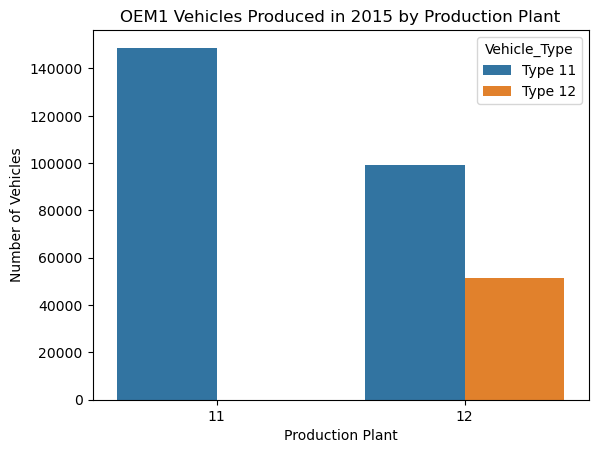

In [103]:
vehicle_plants = pd.concat([
    OEM1_Typ11.assign(Vehicle_Type="Type 11"),
    OEM1_Typ12.assign(Vehicle_Type="Type 12")
])

plant_counts = (
    vehicle_plants
    .groupby(["Werksnummer", "Vehicle_Type"])
    .size()
    .reset_index(name="Vehicle_Count")
)

sns.barplot(
    data=plant_counts,
    x="Werksnummer",
    y="Vehicle_Count",
    hue="Vehicle_Type"
)

plt.title("OEM1 Vehicles Produced in 2015 by Production Plant")
plt.xlabel("Production Plant")
plt.ylabel("Number of Vehicles")
plt.show()

The exploration shows that there are 247,868 unique Type 11 vehicles and 51,385 unique Type 12 vehicles produced in 2015, with no duplicated vehicle IDs. The filtering was successful, as all production dates fall within the year 2015. Furthermore, no missing values were identified in either dataset.

Both datasets contain a constant manufacturer number (`Herstellernummer`), since all vehicles are produced by `OEM1`. Notably, Type 11 vehicles produced in 2015 originate from both plants (`Werksnummer`) 11 and 12, whereas Type 12 vehicles are produced exclusively in plant 12.

## 3.2 Component_Vehicle relational tables

To access the components installed in the previously imported vehicles, the corresponding relational tables are now imported and briefly explored. Since the tasks explicitly focuses on OEM1 vehicles, the relevant relational tables are `Bestandteile_Fahrzeuge_OEM1_Typ11` and `Bestandteile_Fahrzeuge_OEM1_Typ12`. The task also explicitly focuses on the gearshift (`Schaltung`) and engine (`Motor`) components. Thefore, all other component types are excluded from the import and analysis.

In [101]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv", sep = ";")

,"""""","""ID_Karosserie""","""ID_Schaltung""","""ID_Sitze""","""ID_Motor""","""ID_Fahrzeug""\n"
0,"""1""","""K4-112-1121-3""","""K3SG1-105-1051-32""","""K2LE1-109-1091-2""","""K1BE1-101-1011-7""","""11-1-11-1""\n"


In [102]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ12.csv", sep = ";")

,"""""","""ID_Karosserie""","""ID_Schaltung""","""ID_Sitze""","""ID_Motor""","""ID_Fahrzeug""\n"
0,"""1""","""K5-112-1122-1""","""K3SG1-105-1051-4""","""K2ST1-109-1092-1""","""K1BE1-101-1011-90""","""12-1-12-1""\n"


In [12]:
vehicle_components_Typ11 = read_matches(path = "data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv",
                                        usecols = ["ID_Schaltung", "ID_Motor", "ID_Fahrzeug"],
                                        column = "ID_Fahrzeug",
                                        values = set(OEM1_Typ11["ID_Fahrzeug"]),
                                        )

In [15]:
vehicle_components_Typ11.head()

,ID_Schaltung,ID_Motor,ID_Fahrzeug
0,K3SG1-105-1051-581611,K1DI1-102-1021-179721,11-1-12-600034
1,K3SG1-105-1051-581655,K1BE1-101-1011-272075,11-1-12-600035
2,K3SG1-107-1071-871228,K1BE1-104-1041-543705,11-1-12-600036
3,K3SG1-107-1071-871039,K1DI1-103-1031-361823,11-1-12-600037
4,K3SG1-105-1051-581780,K1BE1-101-1011-271827,11-1-12-600038


In [21]:
vehicle_components_Typ12 = read_matches(path = "data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ12.csv",
                                        usecols = ["ID_Schaltung", "ID_Motor", "ID_Fahrzeug"],
                                        column = "ID_Fahrzeug",
                                        values = set(OEM1_Typ12["ID_Fahrzeug"]),
                                        )

In [22]:
vehicle_components_Typ12.head()

,ID_Schaltung,ID_Motor,ID_Fahrzeug
0,K3AG1-105-1051-106456,K1BE1-104-1041-543333,12-1-12-311125
1,K3SG1-105-1051-579466,K1BE1-101-1011-271726,12-1-12-311126
2,K3SG1-105-1051-579474,K1BE1-101-1011-271779,12-1-12-311127
3,K3SG1-105-1051-579534,K1BE1-104-1041-543463,12-1-12-311128
4,K3SG1-105-1051-579640,K1BE1-104-1041-543566,12-1-12-311129


In [28]:
vehicle_components_Typ11.info()
print("-" * 100)
vehicle_components_Typ12.info()

<class 'pandas.DataFrame'>
RangeIndex: 247868 entries, 0 to 247867
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ID_Schaltung  247868 non-null  string
 1   ID_Motor      247868 non-null  string
 2   ID_Fahrzeug   247868 non-null  string
dtypes: string(3)
memory usage: 19.0 MB
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 51385 entries, 0 to 51384
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID_Schaltung  51385 non-null  string
 1   ID_Motor      51385 non-null  string
 2   ID_Fahrzeug   51385 non-null  string
dtypes: string(3)
memory usage: 3.9 MB


In [39]:
vehicle_componentes_overview = pd.DataFrame(
    {
        "Missing values": [vehicle_components_Typ11.isna().sum().sum(), vehicle_components_Typ12.isna().sum().sum()],
        "Duplicated rows" : [vehicle_components_Typ11.duplicated().sum(), vehicle_components_Typ12.duplicated().sum()],
        "Duplicated vehicle IDs" : [vehicle_components_Typ11["ID_Fahrzeug"].duplicated().sum(), vehicle_components_Typ12["ID_Fahrzeug"].duplicated().sum()],
        "Duplicated engine IDs" : [vehicle_components_Typ11["ID_Motor"].duplicated().sum(), vehicle_components_Typ12["ID_Motor"].duplicated().sum()],
        "Duplicated gearshift IDs" : [vehicle_components_Typ11["ID_Schaltung"].duplicated().sum(), vehicle_components_Typ12["ID_Schaltung"].duplicated().sum()]
    },

    index= ["Type 11", "Type 12"]
)

vehicle_componentes_overview

,Missing values,Duplicated rows,Duplicated vehicle IDs,Duplicated engine IDs,Duplicated gearshift IDs
Type 11,0,0,0,0,0
Type 12,0,0,0,0,0


In [42]:
missing_vehicles_typ11 = set(OEM1_Typ11["ID_Fahrzeug"]) - set(vehicle_components_Typ11["ID_Fahrzeug"])

missing_vehicles_typ12 = set(OEM1_Typ12["ID_Fahrzeug"]) - set(vehicle_components_Typ12["ID_Fahrzeug"])

len(missing_vehicles_typ11), len(missing_vehicles_typ12)

(0, 0)

The relational tables were imported according to the selection described above. A short exploration shows that there are no missing values and no duplicated vehicle or component IDs in the imported datasets. Additionally, it is confirmed that each vehicle ID in the vehicle datasets has exactly one corresponding entry in the relational tables.

## 3.3 Component Datasets

### 3.3.1 Importing

To access the relevant component information, the component datasets are imported based on the component IDs identified in the previous section. First, the required component datasets are identified. Afterwards, only records whose component IDs occur in the previously selected vehicle-component relations are imported.

In [71]:
engine_types = pd.concat([
    vehicle_components_Typ11["ID_Motor"],
    vehicle_components_Typ12["ID_Motor"]
]).str.split("-").str[0].unique()

gearshift_types = pd.concat([
    vehicle_components_Typ11["ID_Schaltung"],
    vehicle_components_Typ12["ID_Schaltung"]
]).str.split("-").str[0].unique()

print(f"Engine types: {engine_types}")
print(f"Gearshit types: {gearshift_types}")

Engine types: ['K1DI1' 'K1BE1']
Gearshit types: ['K3SG1' 'K3AG1']


The only engine and gearshift types installed in OEM1 vehicles produced in 2015 are the engines `K1DI1` and `K1BE1` and the gearshifts `K3SG1` and `K3AG1`. Therefore, only the corresponding component datasets are imported.

In [94]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Komponente_K1DI1.csv")

,"""""","""X1""","""ID_Motor.x""","""Produktionsdatum.x""","""Herstellernummer.x""","""Werksnummer.x""","""Fehlerhaft.x""","""Fehlerhaft_Datum.x""","""Fehlerhaft_Fahrleistung.x""","""ID_Motor.y""",...,"""Fehlerhaft.y""","""Fehlerhaft_Datum.y""","""Fehlerhaft_Fahrleistung.y""","""ID_Motor""","""Produktionsdatum""","""Herstellernummer""","""Werksnummer""","""Fehlerhaft""","""Fehlerhaft_Datum""","""Fehlerhaft_Fahrleistung""\n"
0,"""1""",1,"""K1DI1-101-1041-90""",2008-11-13,"""101""",1011,0,NA,0,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA\n


As previously mentioned, `X1` only duplicates the index column, while all columns related to defectiveness are irrelevant to the objective of this analysis. Furthermore, only the columns with the `.x` suffix contain the relevant engine information. Since the production date of the components is not required for the logistics-distance calculation, it is excluded as well. Therefore, only `ID_Motor.x`, `Herstellernummer.x`, and `Werksnummer.x` are imported and renamed to remove the `.x` suffix.

In [ ]:
engine_k1di1_path = "data/IDA SoSe26 - Data/Komponente_K1DI1.csv"
